# Trajectory and velocity analysis of scRNAseq COLON data 

This is one in the series of notebooks presenting the data analysis done in the study "Widespread epithelial dedifferentiation in patients with ulcerative colitis". It is also intended as a tutorial in scRNAseq analysis. Please refer to the REAMDE file for the description of different parts of the tutorial and how to follow it.  

## Part 3. Dimentionality reduction

### Healthy progenitors dataset

This notebook shows the pipeline done on the "Healthy progenitor dataset" (see study for details regarding samples constituting the dataset). Healthy progeniotors are the cells from the healthy dataset that were determined (in Part 2) to be in the G2M or S cell cycle phase and as such are such are understood to be progenitors of the more differentiated cells. I am not providing detailed descriptions of each step here. Those can be found in the notebook for the Healthy dataset. Please refer to the file `Healthy_norm.ipynb`

#### 0. Imports and settings

In [1]:
import scanpy as sc
import scvelo as scv
import matplotlib.pyplot as plt

#### 1. Load data

First lets load the file we have prepared in the previous part of the tutorial.

In [2]:
adata = sc.read('healthy_norm_progen.h5ad')

#### 2. PCA

In [3]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=False)

In [4]:
sc.tl.pca(adata, svd_solver='arpack')

In [5]:
scv.settings.set_figure_params('scvelo', dpi=75, vector_friendly=True, figsize=[6,6])

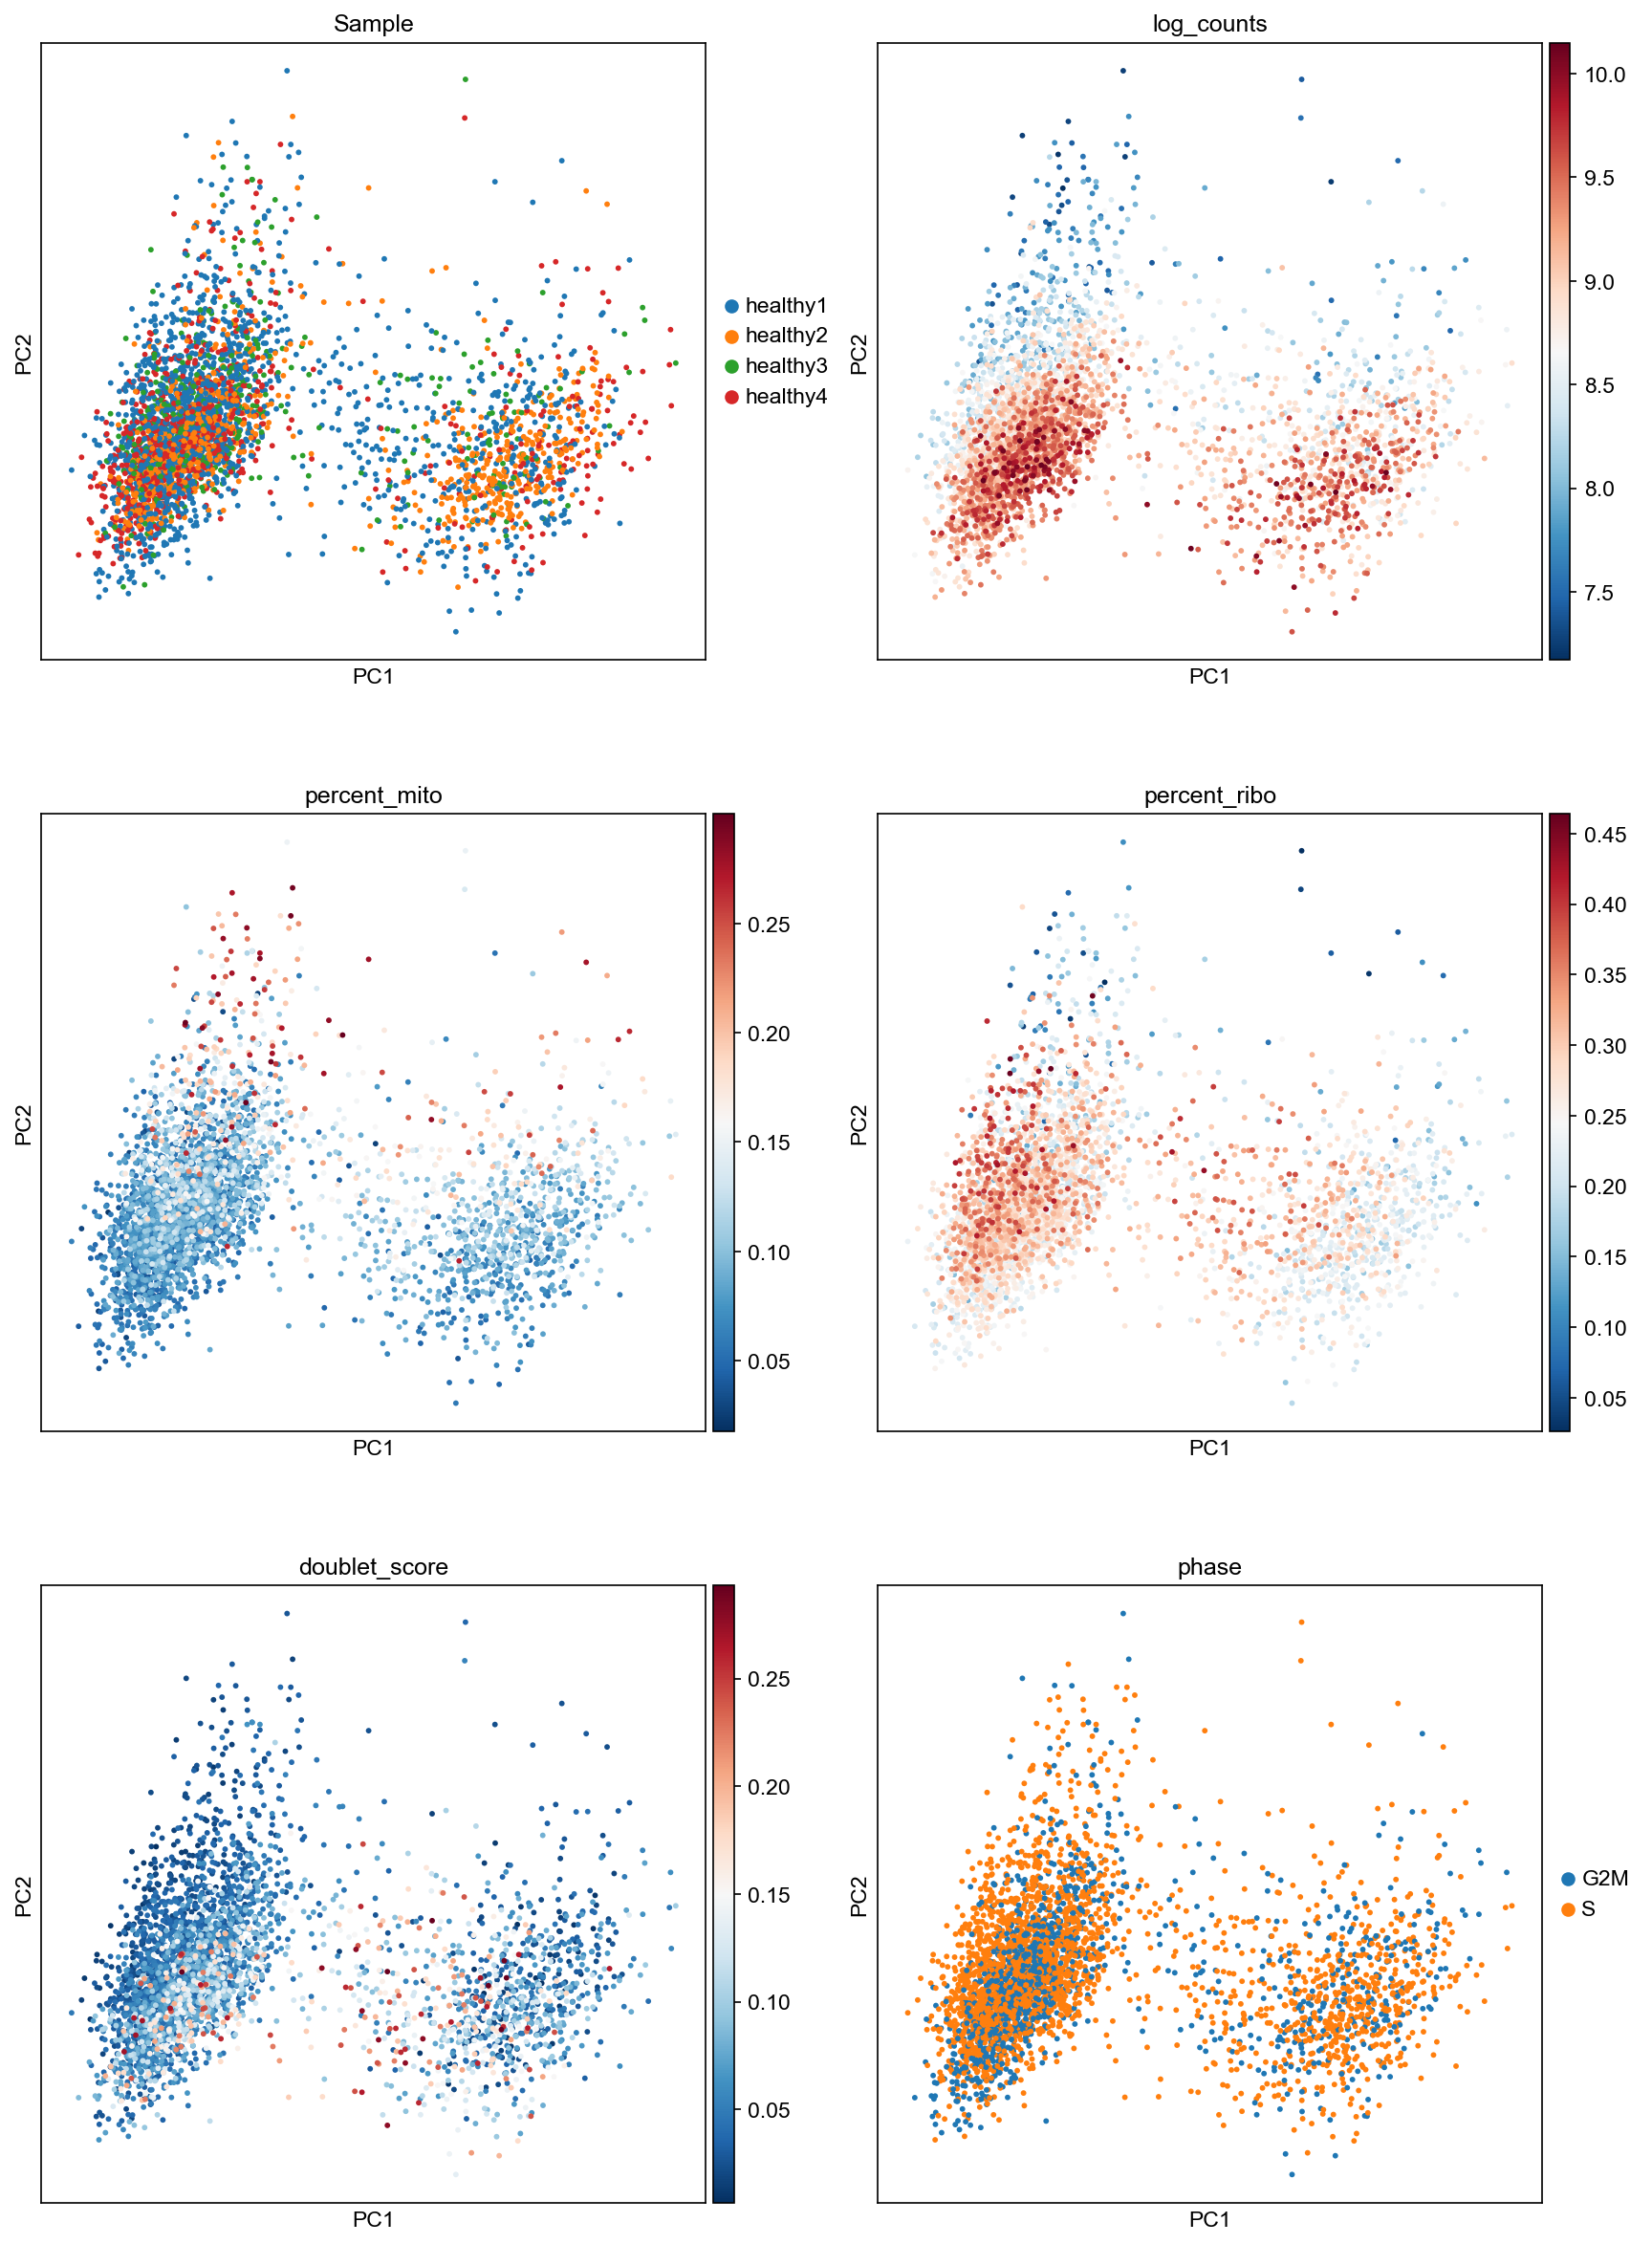

In [6]:
features = ['Sample', 'log_counts', 'percent_mito', 'percent_ribo', 'doublet_score', 'phase']
sc.pl.pca(adata, color=features, ncols=2)

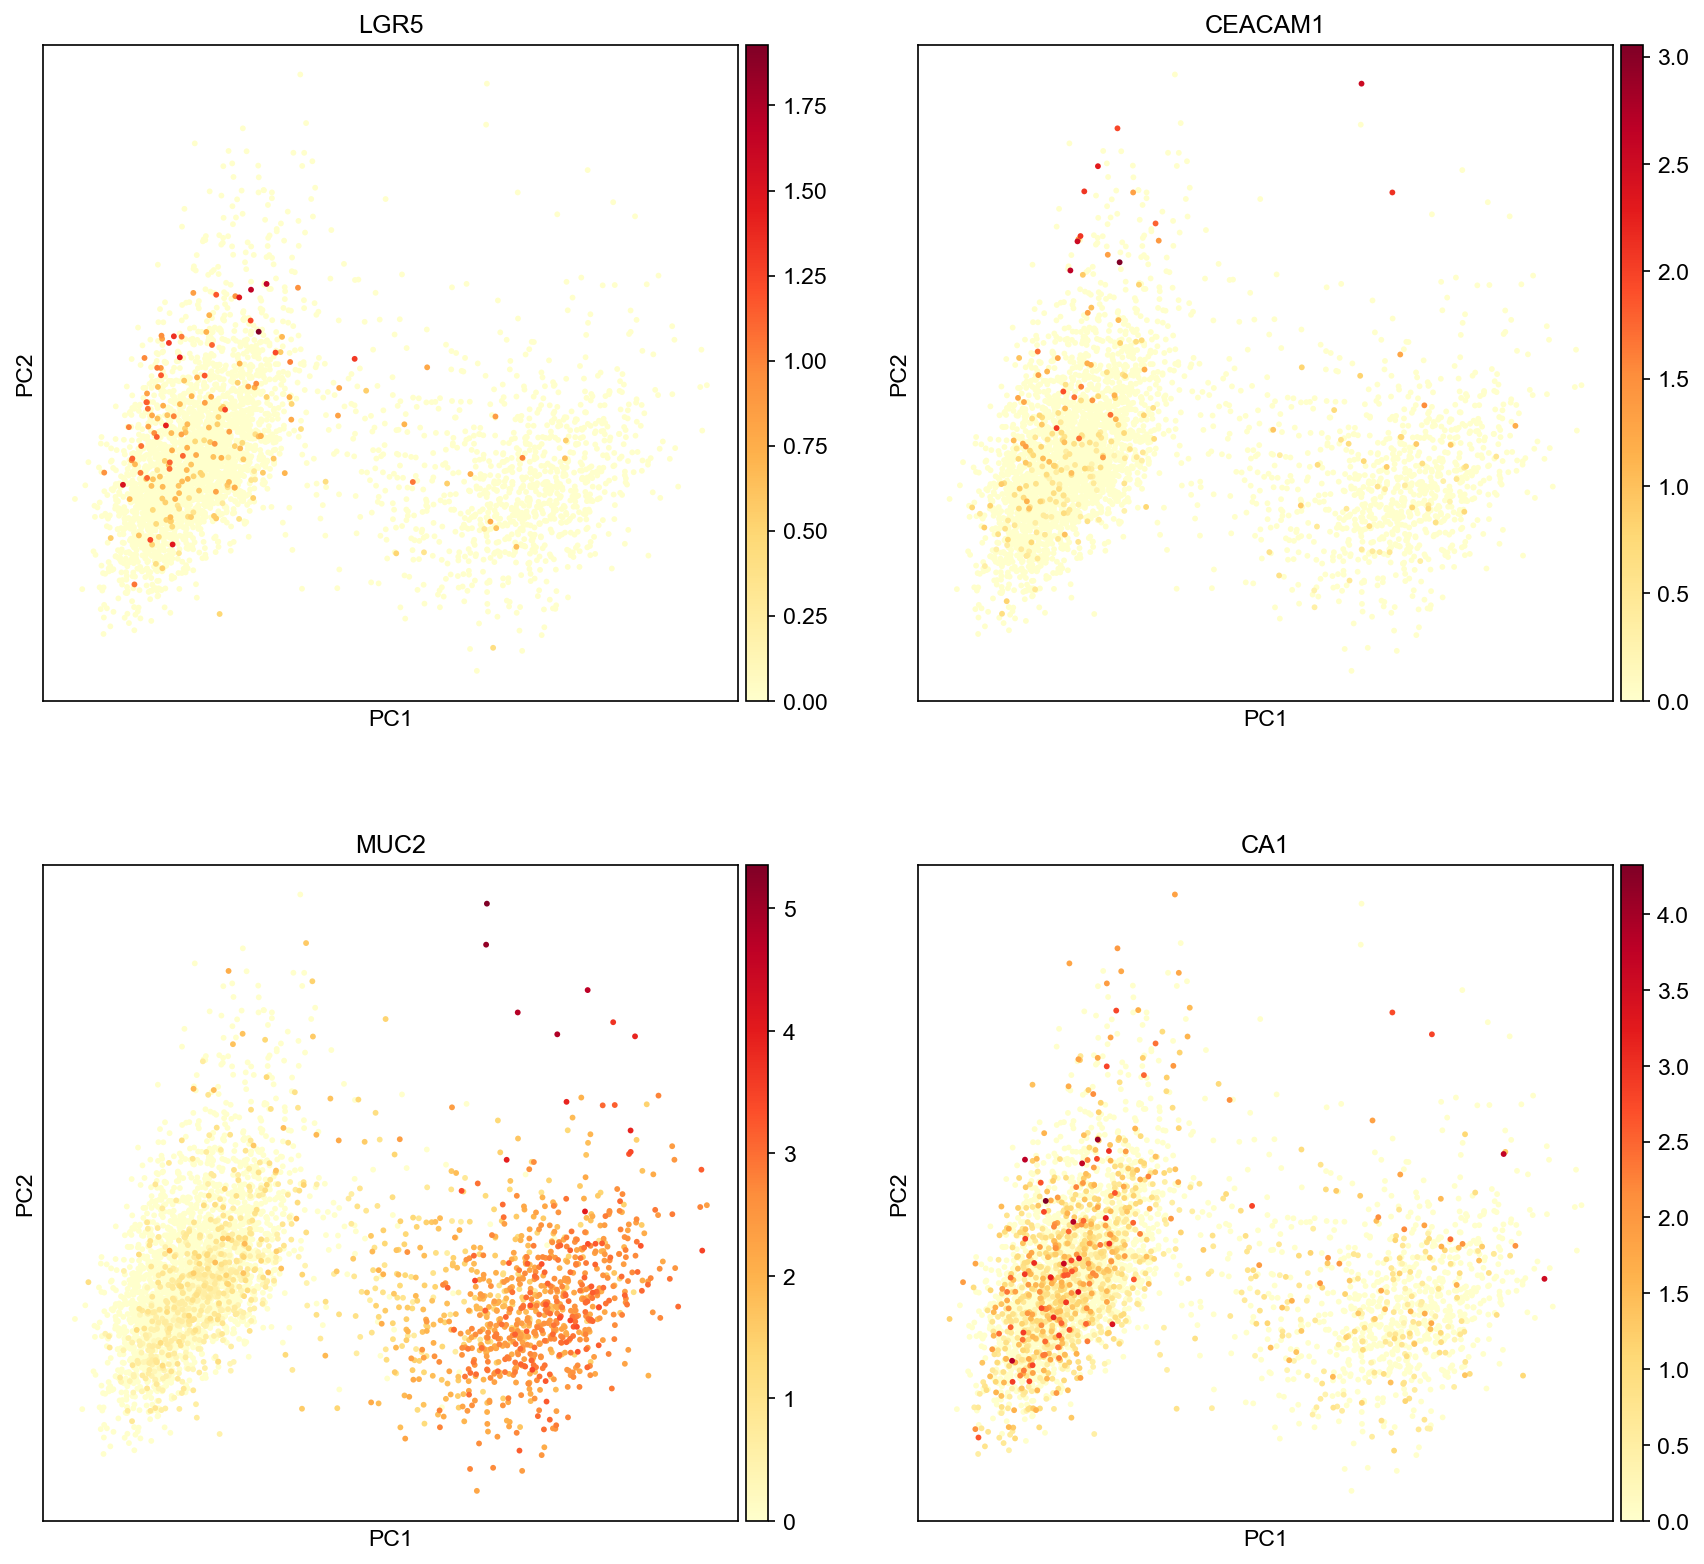

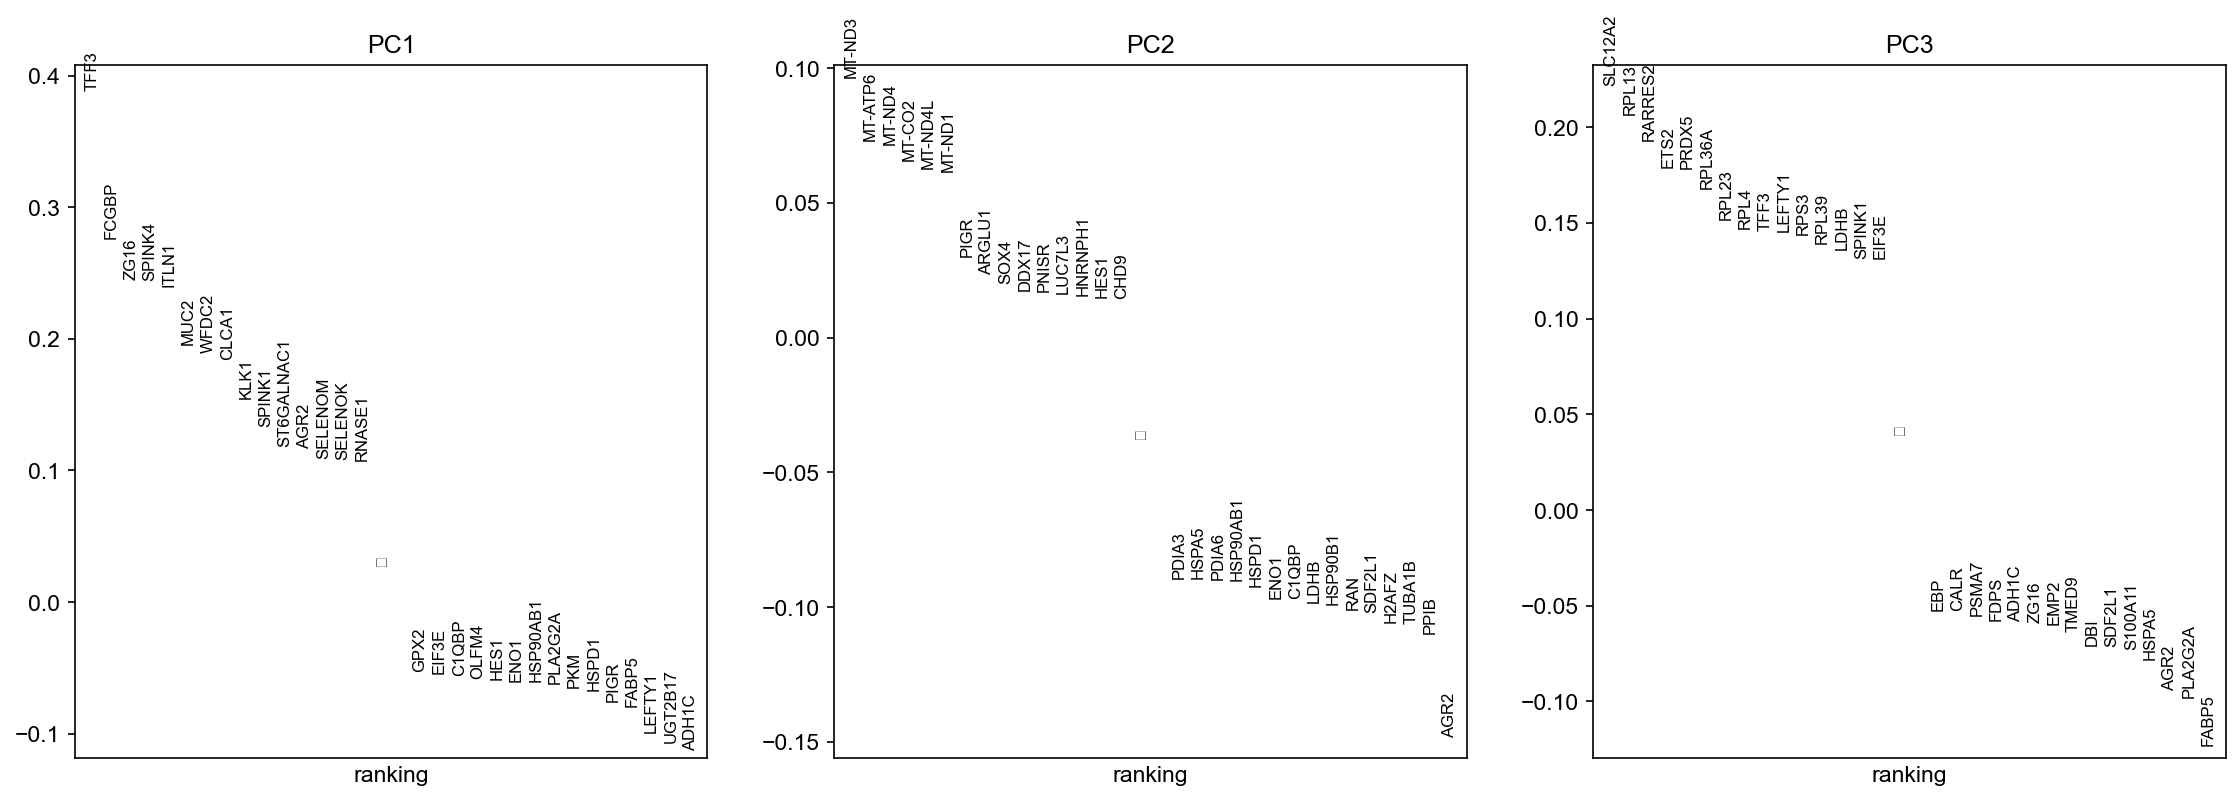

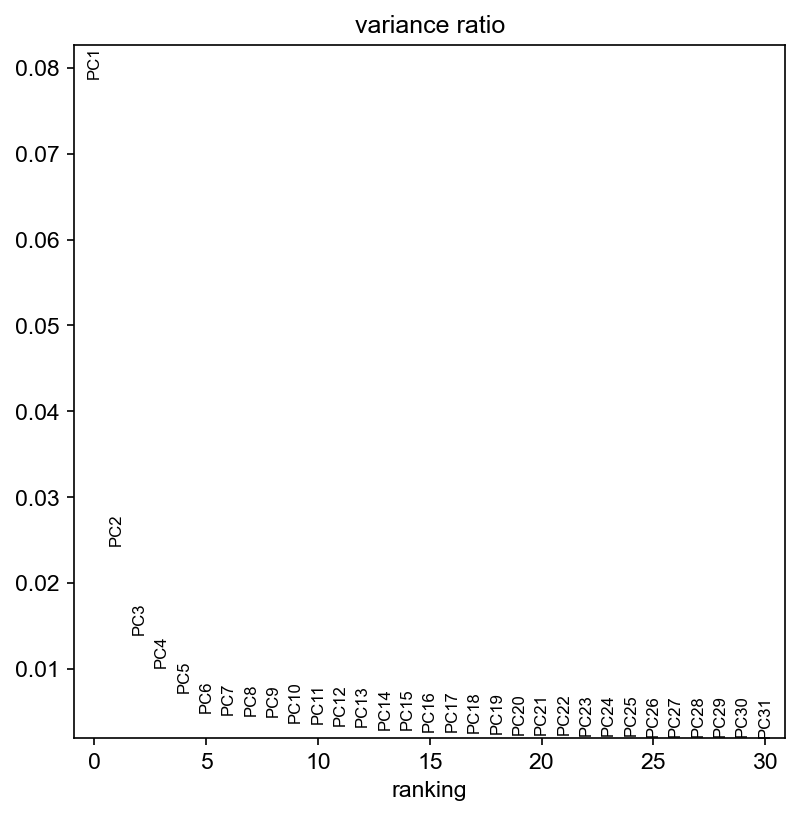

In [7]:
features = ['LGR5', 'CEACAM1', 'MUC2', 'CA1']
sc.pl.pca_overview(adata, color=features, ncols=2, components=['1,2'], cmap='YlOrRd')

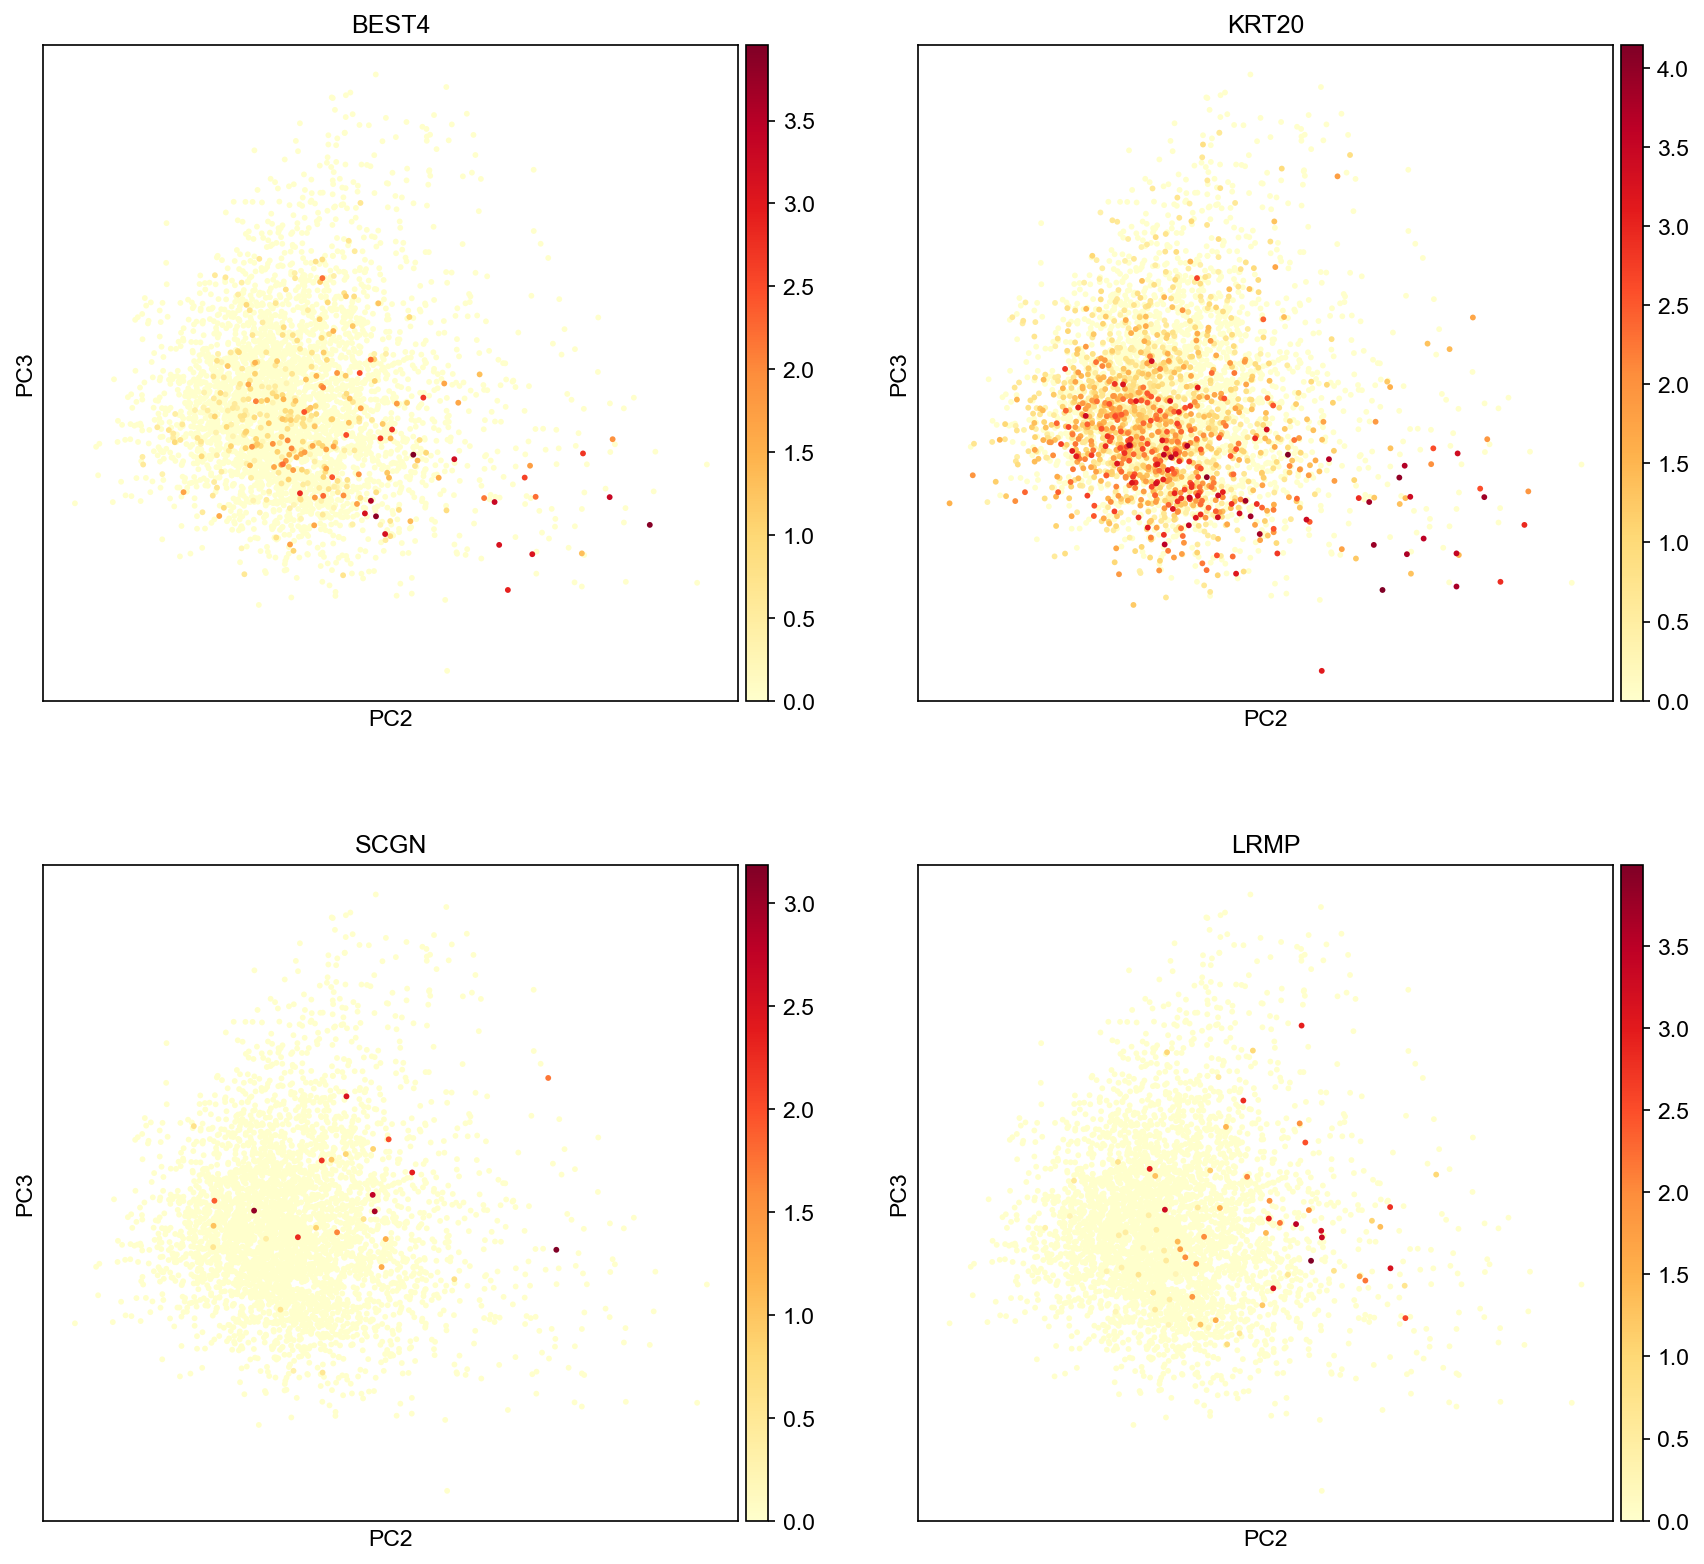

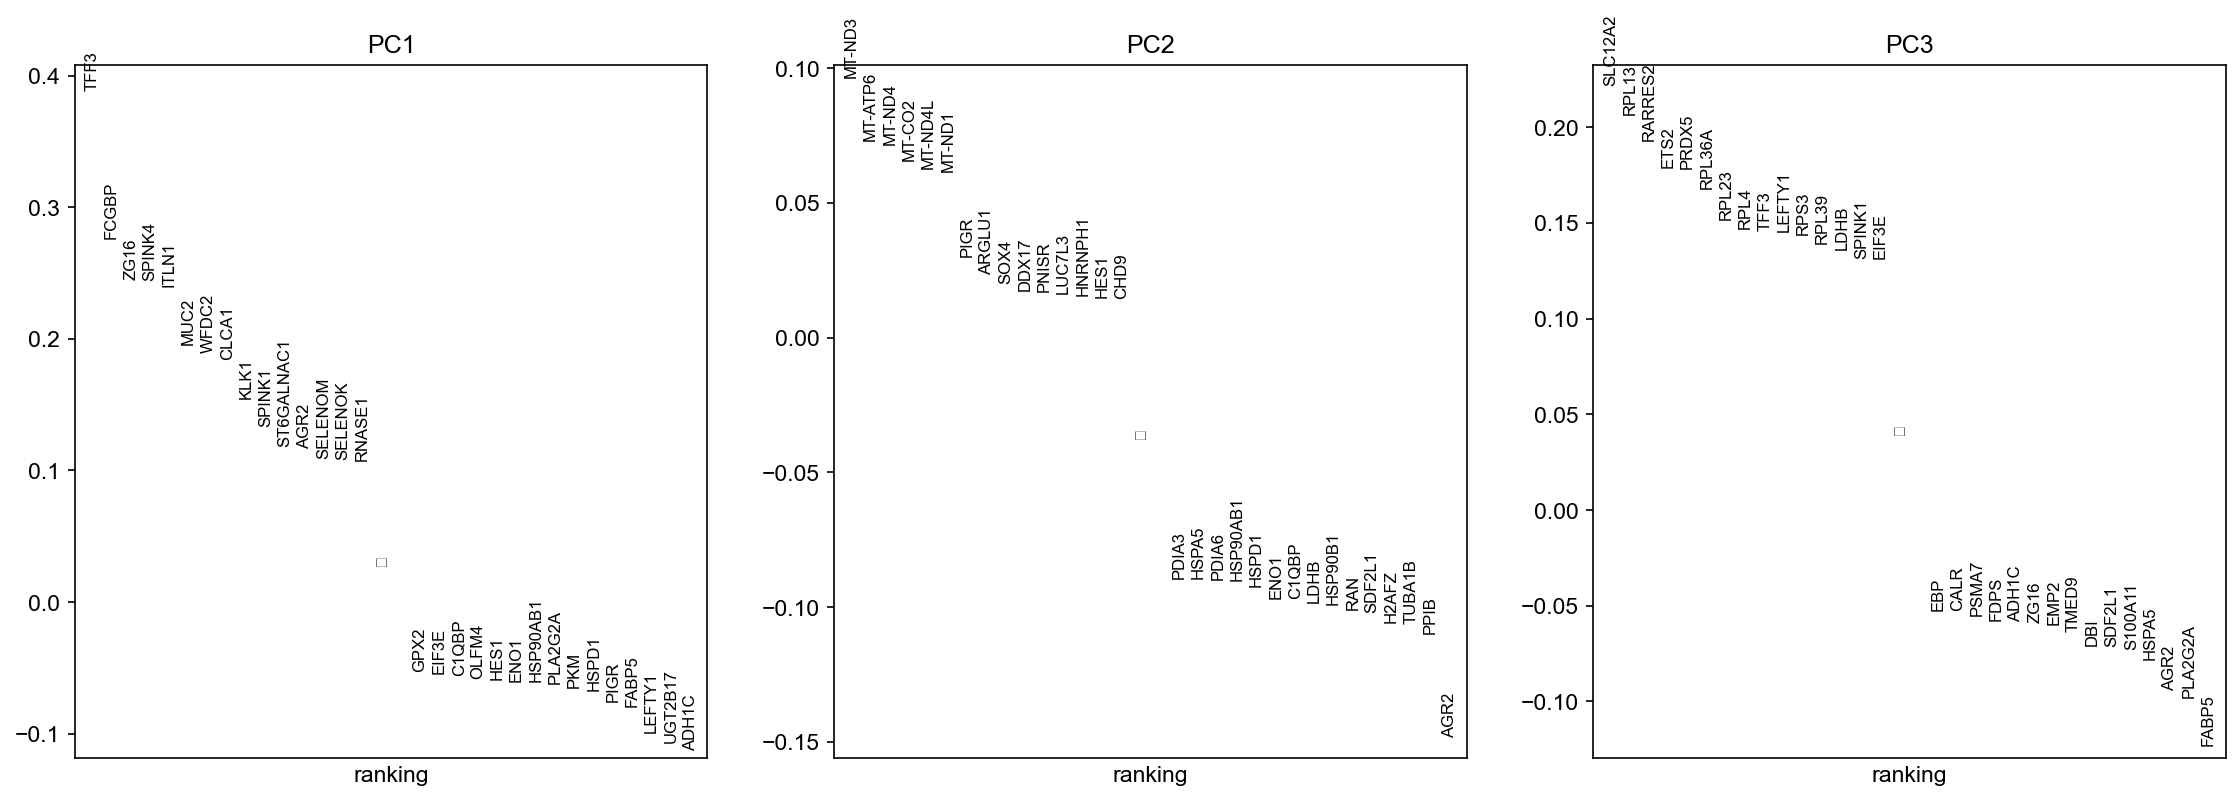

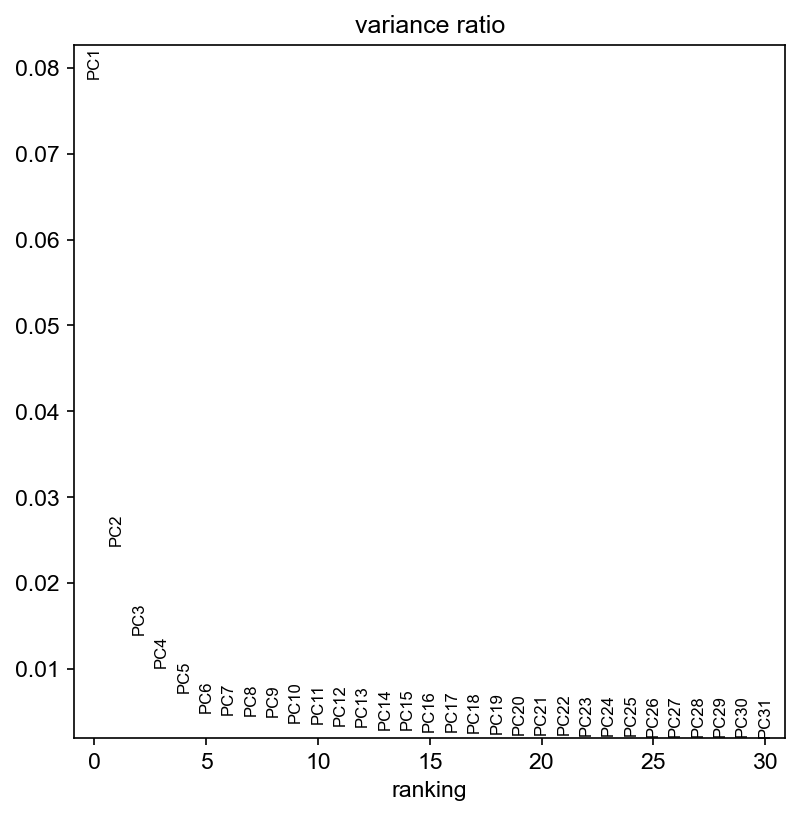

In [8]:
features = ['BEST4', 'KRT20', 'SCGN', 'LRMP']
sc.pl.pca_overview(adata, color=features, ncols=2, components=['2,3'], cmap='YlOrRd')

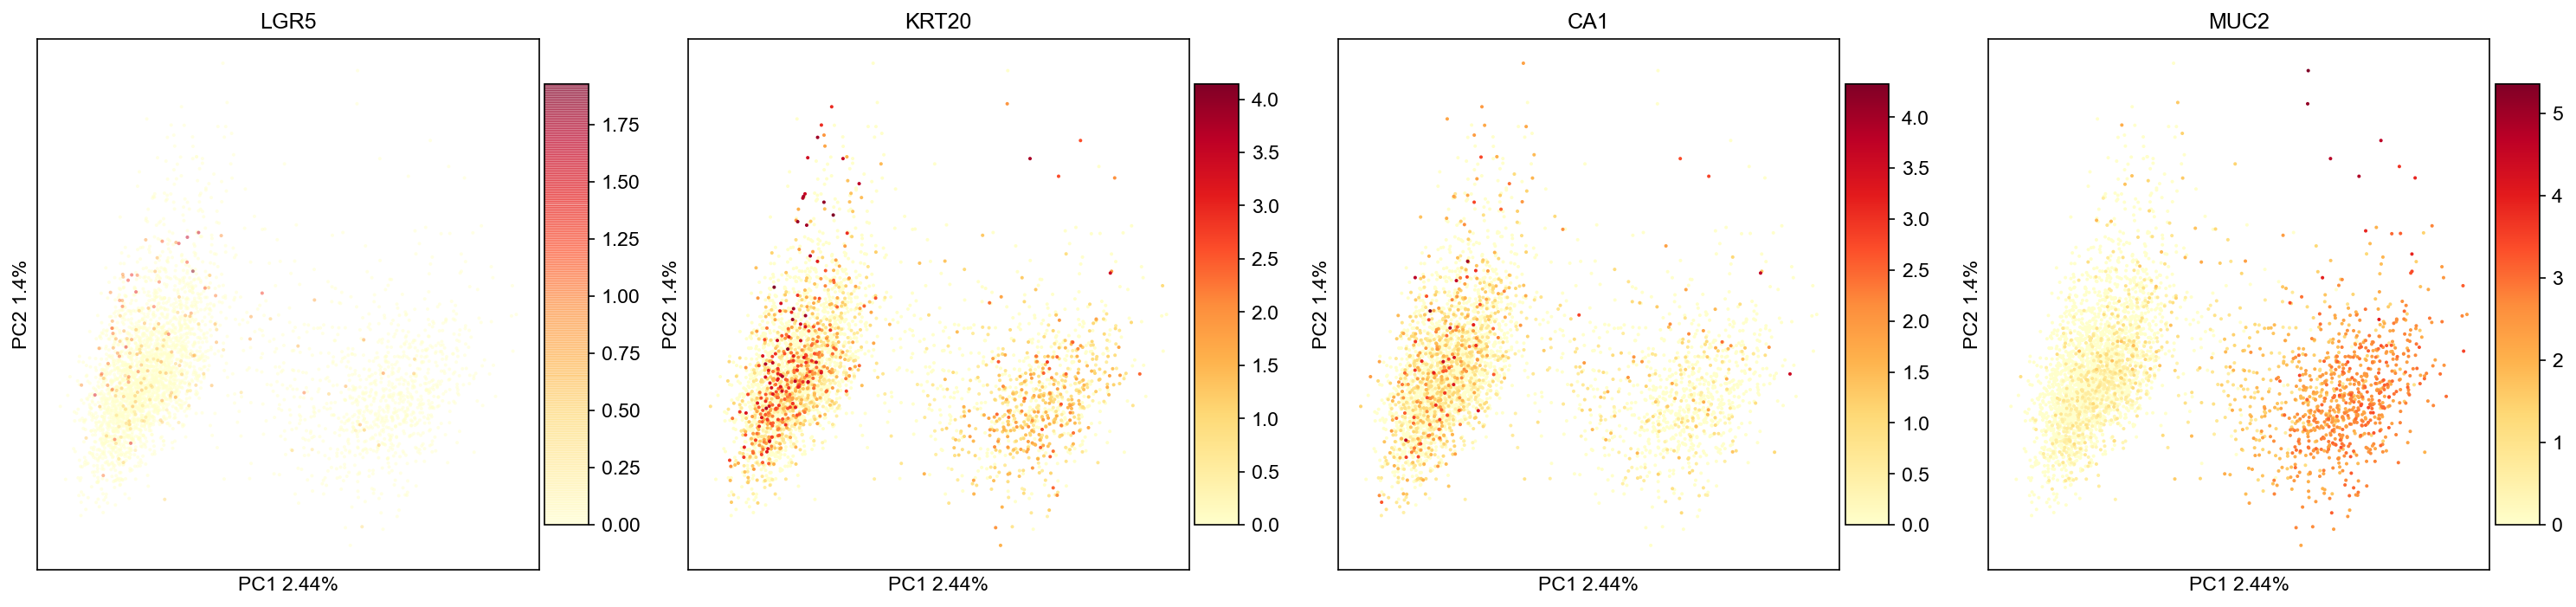

In [9]:
# This long code lets you plot multiple genes in one figure with axis labels showing the amount of variance explained by a PC.
# You can of course show other variables, not only genes.
# PCX, PCY should be integers corresponding to PCs you want to plot on X and Y axis

def labelled_PCA_plot(PCX, PCY, gene1, gene2, gene3, gene4):

    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20,10))

    sc.pl.pca(adata, color=gene1, cmap='YlOrRd', alpha=0.5, ax=ax1, show=False, size=15, components=['{},{}'.format(PCX,PCY)])
    adata.uns['pca']['variance_ratio']
    ax1.set_aspect(aspect=1)
    ax1.set_xlabel('PC{} {}%'.format(PCX, round(adata.uns['pca']['variance_ratio'][PCX]*100, 2)))
    ax1.set_ylabel('PC{} {}%'.format(PCY, round(adata.uns['pca']['variance_ratio'][PCY]*100, 2)))
    fig = plt.gcf()
    cbar_ax = fig.axes[-1]
    cbar_ax.set_aspect(aspect=10)

    sc.pl.pca(adata, color=gene2, cmap='YlOrRd', ax=ax2, show=False, size=15, components=['{},{}'.format(PCX,PCY)])
    ax2.set_aspect(aspect=1)
    ax2.set_xlabel('PC{} {}%'.format(PCX, round(adata.uns['pca']['variance_ratio'][PCX]*100, 2)))
    ax2.set_ylabel('PC{} {}%'.format(PCY, round(adata.uns['pca']['variance_ratio'][PCY]*100, 2)))
    fig = plt.gcf()
    cbar_ax = fig.axes[-1]
    cbar_ax.set_aspect(aspect=10)

    sc.pl.pca(adata, color=gene3, cmap='YlOrRd', ax=ax3, show=False, size=15, components=['{},{}'.format(PCX,PCY)])
    ax3.set_aspect(aspect=1)
    ax3.set_xlabel('PC{} {}%'.format(PCX, round(adata.uns['pca']['variance_ratio'][PCX]*100, 2)))
    ax3.set_ylabel('PC{} {}%'.format(PCY, round(adata.uns['pca']['variance_ratio'][PCY]*100, 2)))
    fig = plt.gcf()
    cbar_ax = fig.axes[-1]
    cbar_ax.set_aspect(aspect=10)

    sc.pl.pca(adata, color=gene4, cmap='YlOrRd', ax=ax4, show=False, size=15, components=['{},{}'.format(PCX,PCY)])
    ax4.set_aspect(aspect=1)
    ax4.set_xlabel('PC{} {}%'.format(PCX, round(adata.uns['pca']['variance_ratio'][PCX]*100, 2)))
    ax4.set_ylabel('PC{} {}%'.format(PCY, round(adata.uns['pca']['variance_ratio'][PCY]*100, 2)))
    fig = plt.gcf()
    cbar_ax = fig.axes[-1]
    cbar_ax.set_aspect(aspect=10)

    fig.tight_layout()
    
labelled_PCA_plot(PCX=1, PCY=2, gene1='LGR5', gene2='KRT20', gene3='CA1', gene4='MUC2')

#### 3. Batch correction with bbknn

In [10]:
sc.external.pp.bbknn(adata, batch_key='Sample', neighbors_within_batch=5, n_pcs=30,
                     approx=False, use_faiss=False, metric='euclidean')

#### 4. UMAP

In [11]:
sc.tl.umap(adata)

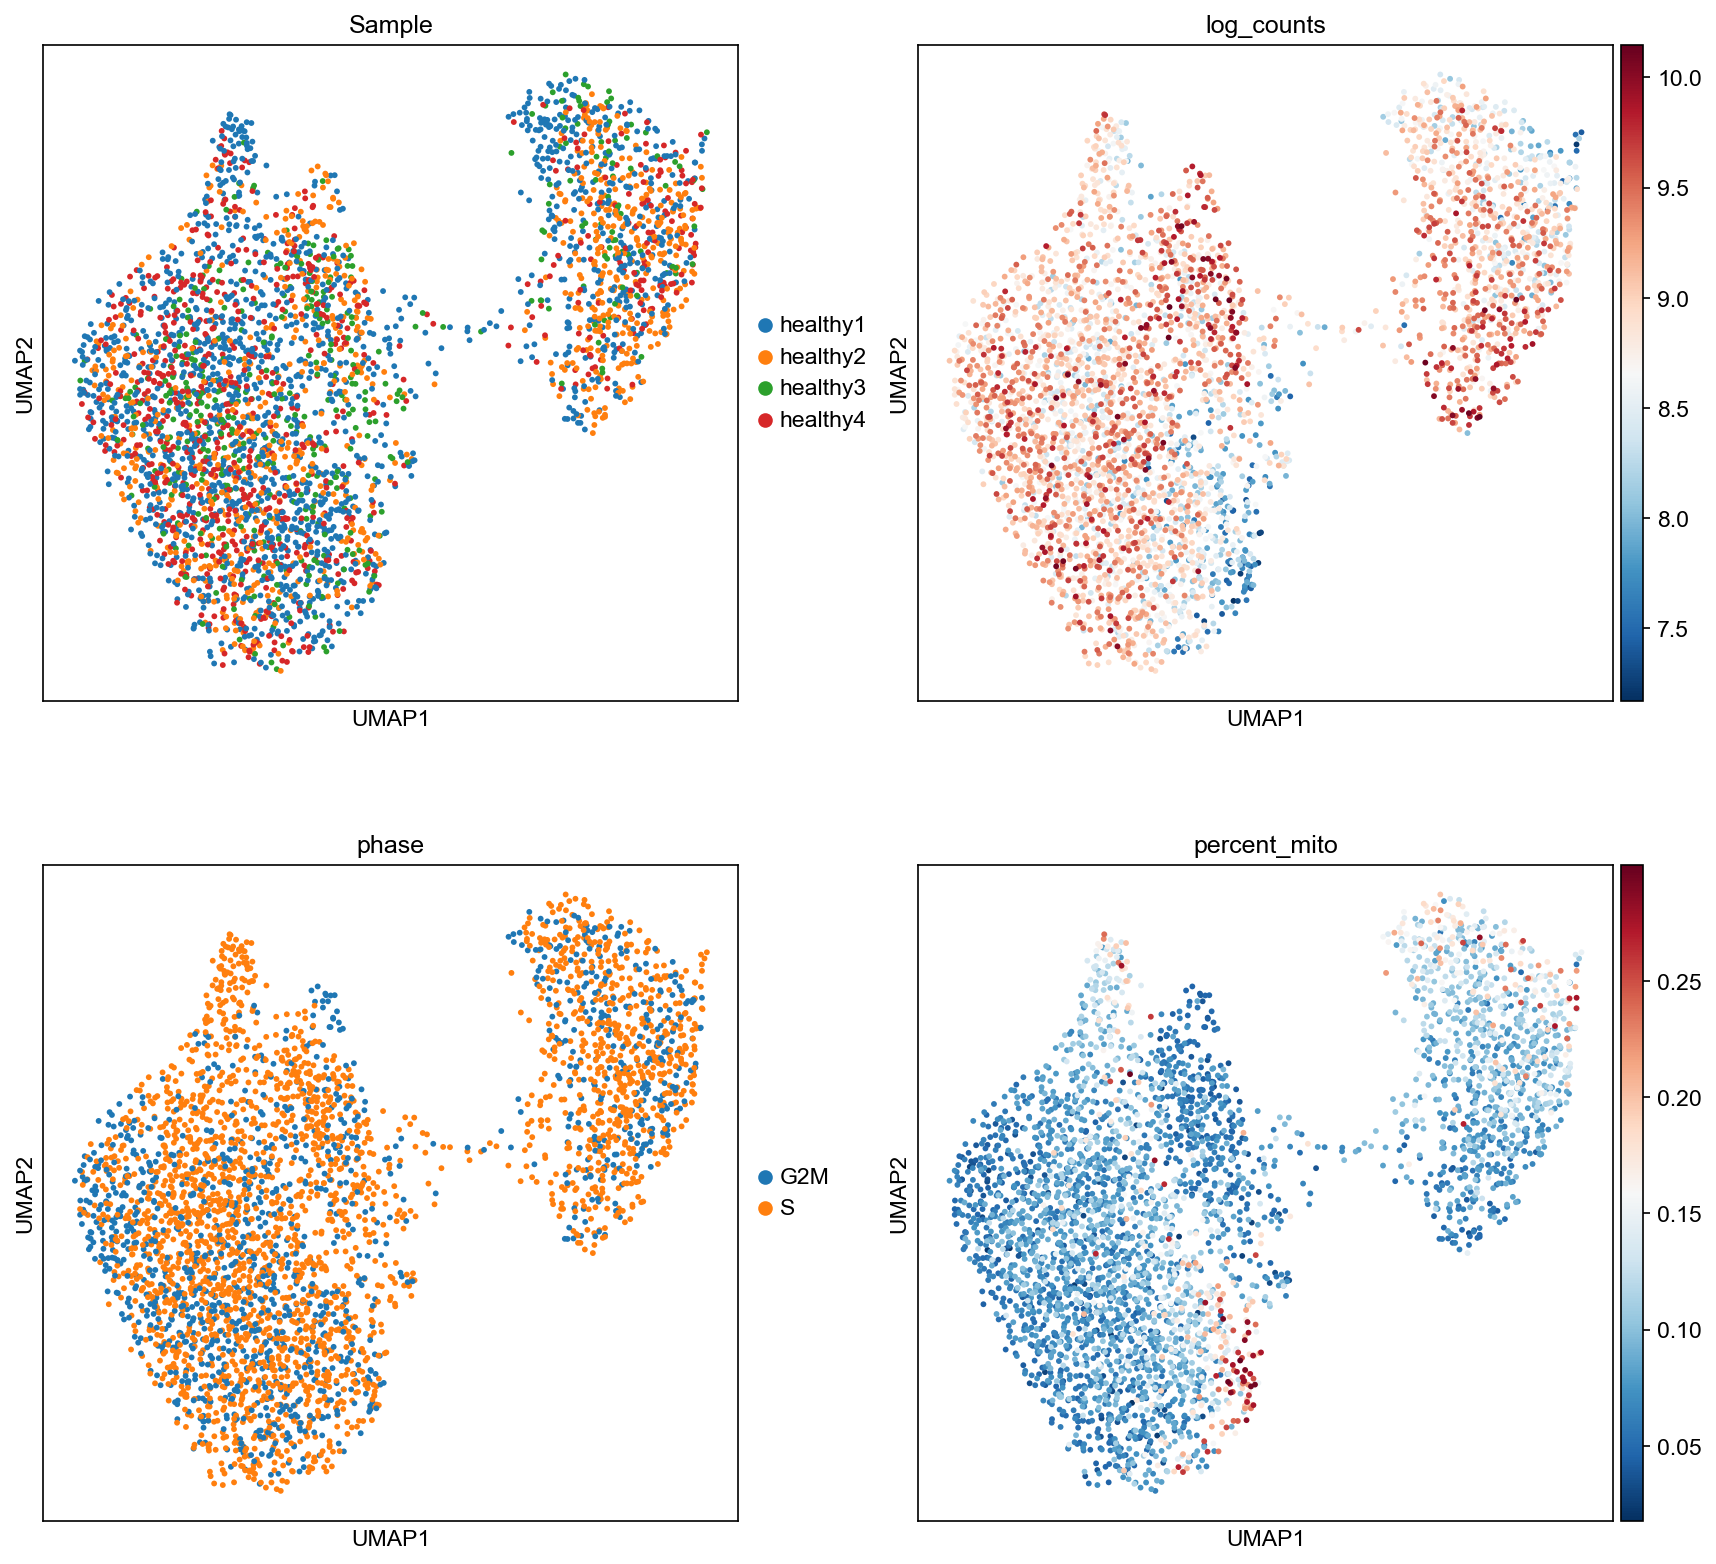

In [12]:
features = ['Sample', 'log_counts', 'phase', 'percent_mito']

sc.pl.umap(adata, color=features, ncols=2)

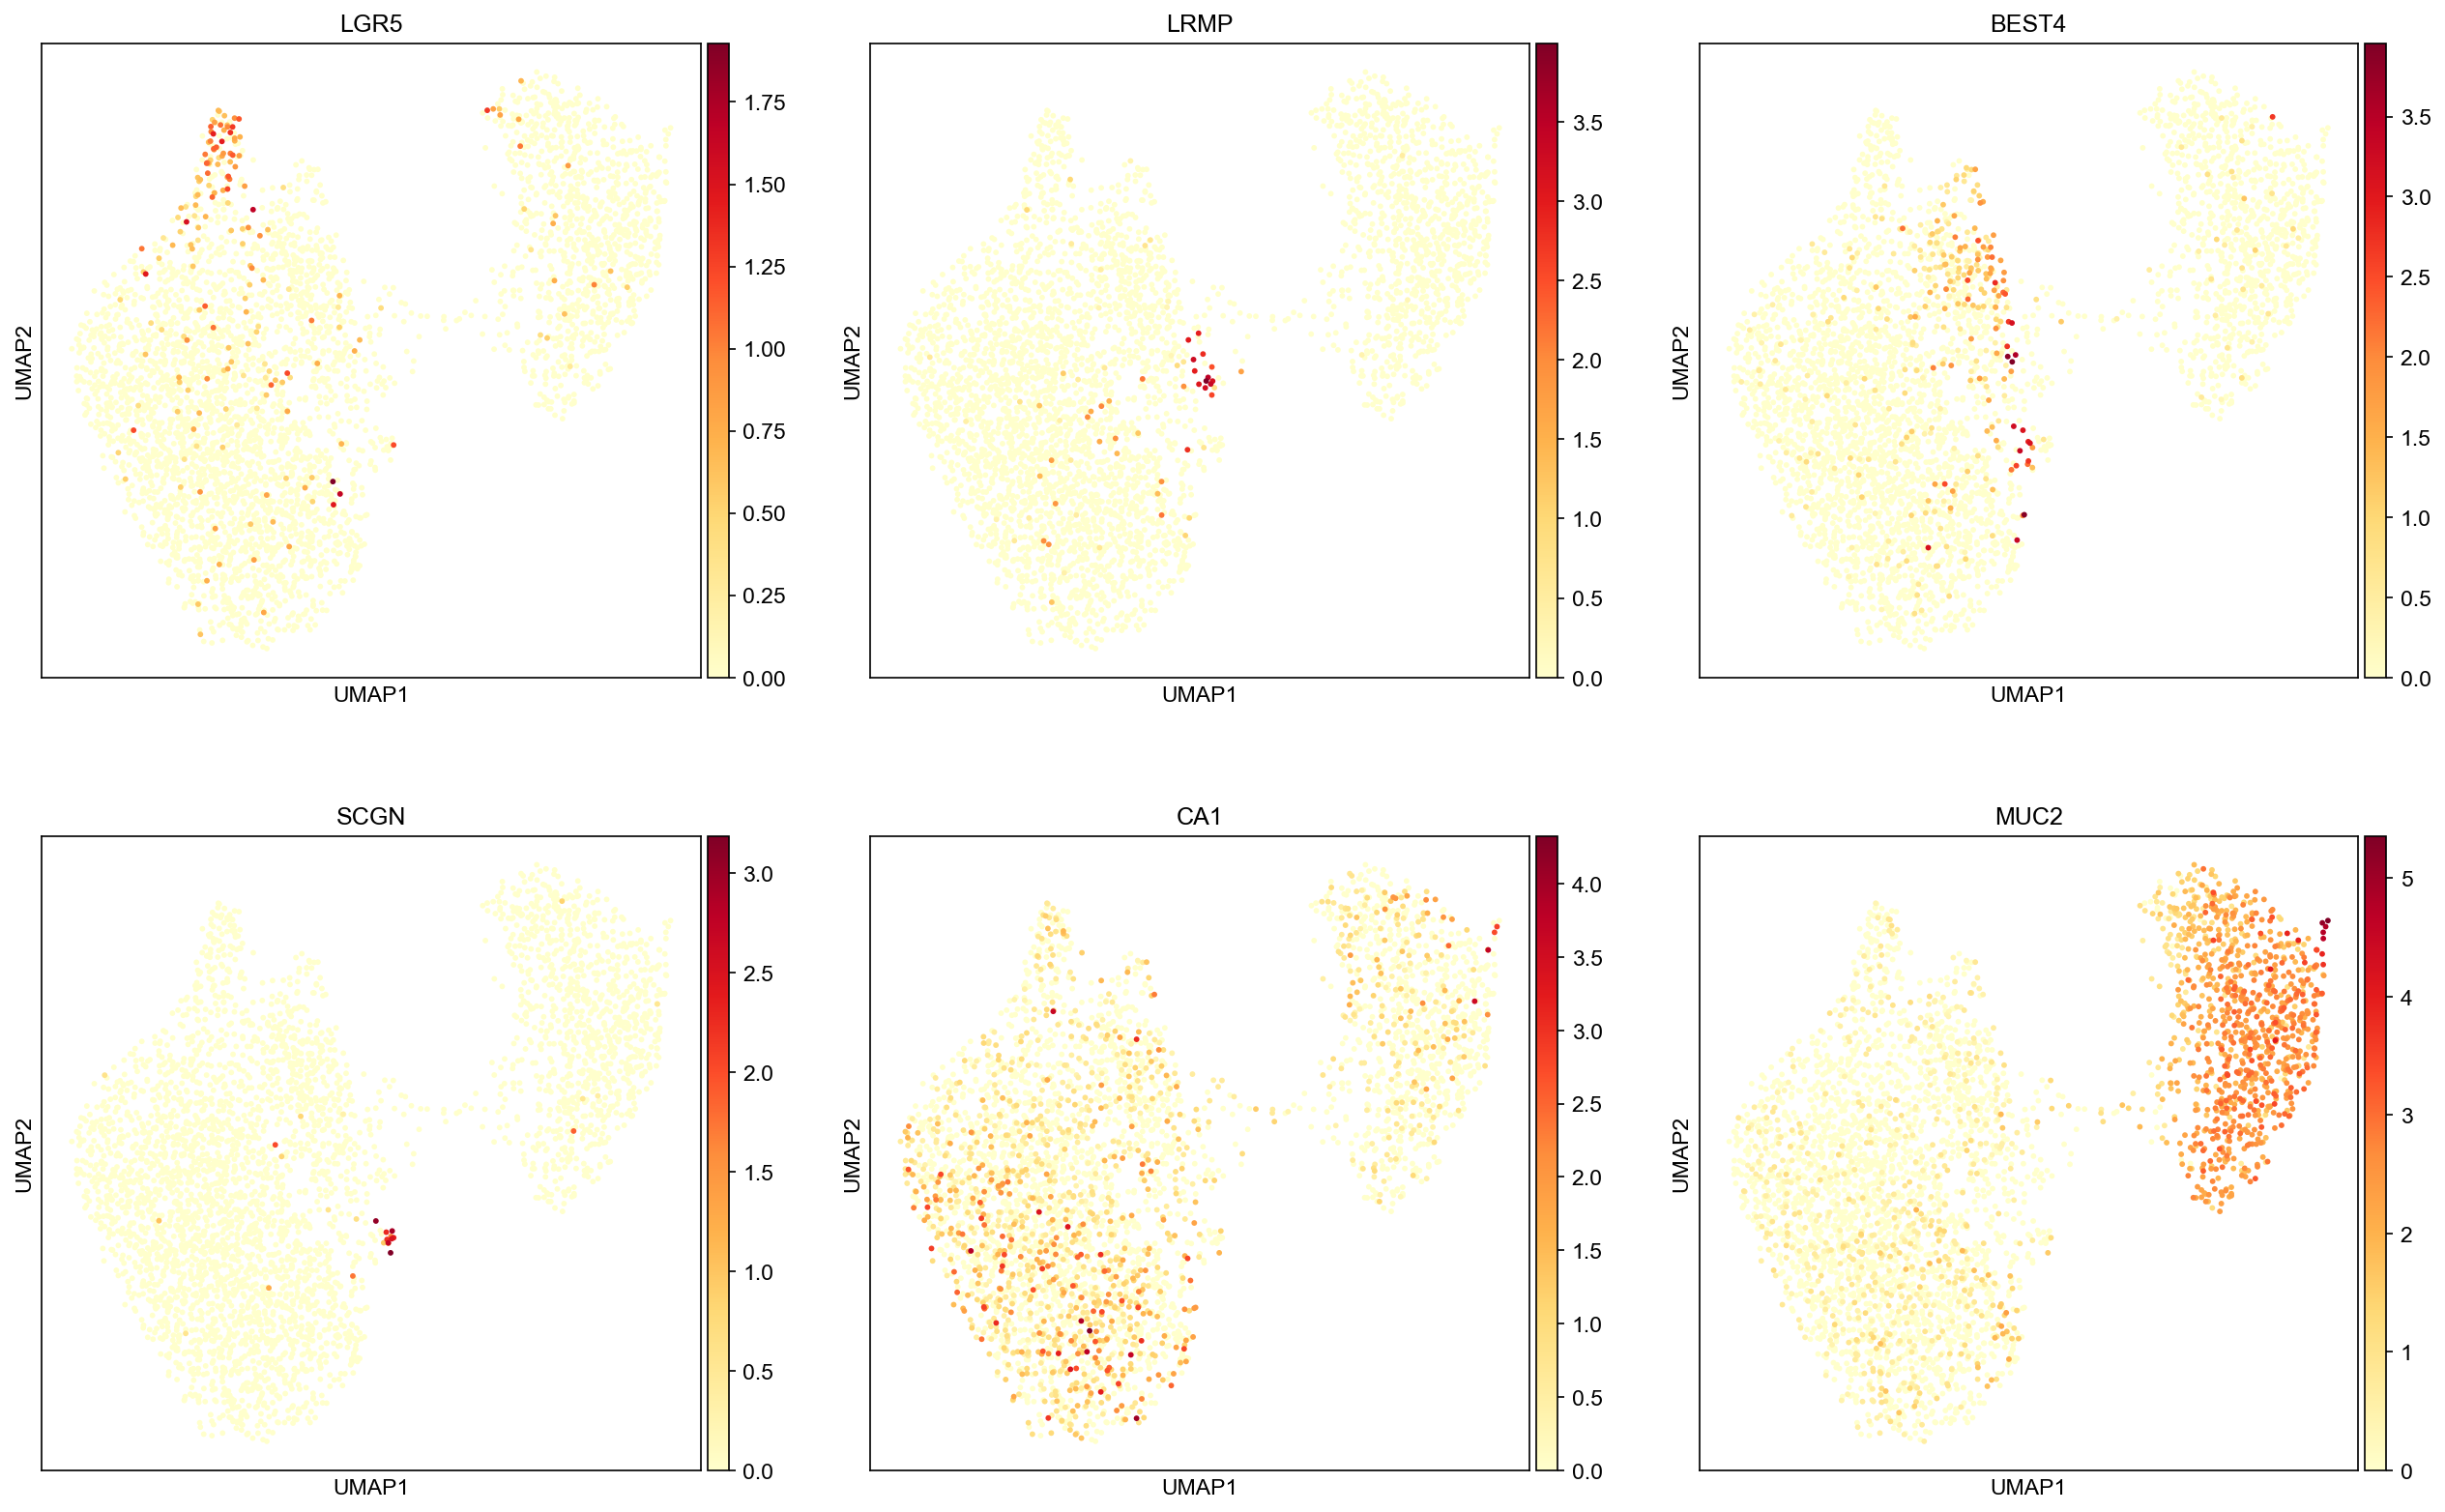

In [13]:
features = ['LGR5', 'LRMP', 'BEST4', 'SCGN', 'CA1', 'MUC2']

sc.pl.umap(adata, color=features, use_raw=True, ncols=3, cmap='YlOrRd')

#### 5.Save data for the next step 

In [14]:
adata.write("healthy_dr_progen.h5ad")